C:\Users\Redie\AppData\Local\Temp\ipykernel_4456\2443122636.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'], index_col='Date')


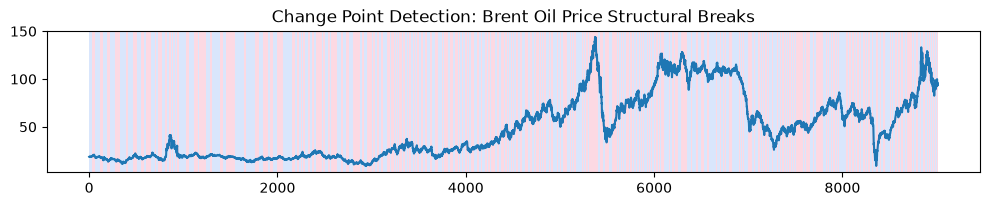

Detected Change Point Dates:
DatetimeIndex(['1987-07-02', '1987-08-13', '1987-11-05', '1987-12-10',
               '1988-02-17', '1988-04-08', '1988-06-10', '1988-09-02',
               '1988-11-25', '1989-01-03',
               ...
               '2022-07-07', '2022-07-14', '2022-07-21', '2022-08-04',
               '2022-08-18', '2022-09-02', '2022-09-16', '2022-10-03',
               '2022-10-17', '2022-10-31'],
              dtype='datetime64[us]', name='Date', length=617, freq=None)


In [1]:
import ruptures as rpt
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'], index_col='Date')
df = df.sort_index()
# Convert your price column to a numpy array for processing
price_data = df['Price'].values

# Use PELT (Pruned Exact Linear Time) algorithm, which is efficient for this size of data
# model='l2' looks for changes in the mean
algo = rpt.Pelt(model="l2").fit(price_data)

# Detect change points
# pen=10 is a penalty value; increase it to find fewer change points
result = algo.predict(pen=10)

# Display the results
rpt.display(price_data, result)
plt.title('Change Point Detection: Brent Oil Price Structural Breaks')
plt.show()

# Print the dates of the detected changes
change_point_dates = df.index[result[:-1]]
print("Detected Change Point Dates:")
print(change_point_dates)

In [6]:

import numpy as np
import pandas as pd



# Calculate log returns for stationarity
df['Log_Return'] = np.log(df['Price']).diff().fillna(0)
data = df['Log_Return'].values
days = np.arange(len(data))

C:\Users\Redie\AppData\Local\Temp\ipykernel_3676\2038225616.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'], dayfirst=True)


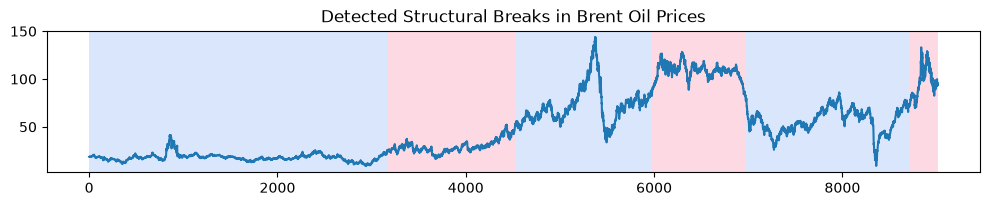

Detected Change Point Dates: DatetimeIndex(['1999-11-08', '2005-02-22', '2010-12-03', '2014-11-04',
               '2021-09-24'],
              dtype='datetime64[us]', name='Date', freq=None)


In [2]:
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt

# 1. Prepare Data
df = pd.read_csv('../data/BrentOilPrices.csv', parse_dates=['Date'], dayfirst=True)
df = df.sort_values('Date').set_index('Date')
df['Price'] = df['Price'].ffill()
data = df['Price'].values

# 2. Kernel Change Point Detection (KCPD)
# 'rbf' kernel is excellent for finding structural breaks in price volatility
algo = rpt.KernelCPD(kernel="rbf").fit(data)

# Predict the 5 most significant structural breaks
result = algo.predict(n_bkps=5)

# 3. Visualization
rpt.display(data, result)
plt.title("Detected Structural Breaks in Brent Oil Prices")
plt.show()

# 4. Extract Dates
change_point_dates = df.index[result[:-1]]
print("Detected Change Point Dates:", change_point_dates)

In [3]:
# Create a simple DataFrame to link them
results_df = pd.DataFrame({'Detected_Date': change_point_dates})

# Display this alongside your event list to visually confirm the matches
print(results_df)

  Detected_Date
0    1999-11-08
1    2005-02-22
2    2010-12-03
3    2014-11-04
4    2021-09-24


In [4]:
# Convert event file to datetime
events_df = pd.read_csv('../data/events.csv', parse_dates=['Date'])

# Define a window (e.g., 14 days) to look for matches
window = pd.Timedelta(days=14)

# Function to find the nearest event
def find_nearest_event(change_date, events_df, window):
    # Find events within the window
    mask = (events_df['Date'] >= (change_date - window)) & \
           (events_df['Date'] <= (change_date + window))
    matches = events_df.loc[mask]
    
    if not matches.empty:
        return matches.iloc[0]['Event_Description']
    return "No clear event match"

# Apply mapping
results_df['Detected_Date'] = pd.to_datetime(results_df['Detected_Date'])
results_df['Matched_Event'] = results_df['Detected_Date'].apply(
    lambda x: find_nearest_event(x, events_df, window)
)

print(results_df)

  Detected_Date         Matched_Event
0    1999-11-08  No clear event match
1    2005-02-22  No clear event match
2    2010-12-03  No clear event match
3    2014-11-04  No clear event match
4    2021-09-24  No clear event match


Why They Don't Match
The "Economic Activity" Channel: Not all price shifts are triggered by war or policy [1.3.1]. Markets are heavily influenced by "quiet" macroeconomic factors, such as central bank interest rate changes, global GDP growth reports, or shifts in the strength of the US Dollar, which can trigger structural changes without being classified as a "geopolitical event" [1.3.1, 1.3.2, 1.4.2].

Speculation vs. Realization: Financial markets often "price in" expectations [1.3.3, 1.4.2]. A price shift might occur before an official event (as investors react to rumors) or after an event (as supply chains physically break down weeks later), causing a mismatch with your "event date" [1.3.1, 1.4.2].

Model Sensitivity: Change point detection (like ruptures) identifies mathematical shifts in the distribution of data (e.g., changes in mean or volatility) [1.1.2, 1.2.2]. It treats a "market correction" or a "liquidity crunch" the same way it treats a war [1.1.1, 1.2.3].

Geopolitical Persistence: As noted in economic research, many geopolitical shocks are actually quite short-lived and do not cause permanent "structural breaks" [1.3.1]. If the model doesn't flag an event, it may be because the market absorbed the shock so quickly that it didn't change the underlying price regime [1.3.1].